In [1]:
# Import requested libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Read the dataset
data = pd.read_csv(r"../data/processed/telecom_churn_clean.csv")

In [3]:
# Identify the number of row/columns
data.shape
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 3333
Columns: 11


In [4]:
data.columns

Index(['churn', 'account_weeks', 'contract_renewal', 'data_plan', 'data_usage',
       'cust_serv_calls', 'day_mins', 'day_calls', 'monthly_charge',
       'overage_fee', 'roam_mins'],
      dtype='object')

In [5]:
data["churn"].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

In [6]:
# Separate features (X) from the target variable (y)
X = data.drop("churn", axis = 1)

In [7]:
# Define the target variable (y)
y = data["churn"]

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.20,
    random_state = 42,
    stratify = y 
)


In [9]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression()

In [11]:
# Train the Logistic Regression model
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
# Predict churn probabilities for the test set
y_prob = model.predict_proba(X_test_scaled)

In [13]:
y_churn_prob = y_prob[:, 1]

In [14]:
# Predict churn classes for the test set
y_pred = model.predict(X_test_scaled)

In [15]:
# Compare actual and predicted churn values
comparison = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted" : y_pred }
)
comparison

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
662,0,0
663,0,0
664,0,0
665,0,0


In [16]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy * 100 :.2f} %" )

Accuracy : 85.76 %


In [17]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
cm

,Predicted 0,Predicted 1
Actual 0,552,18
Actual 1,77,20


In [18]:
# # Calculate Recall/Precision/F1/ROC-AUC Scores for Model
recall = recall_score(y_test, y_pred)
print(f"Recall score : {recall * 100 :.2f} %")
precision = precision_score(y_test, y_pred)
print(f"Precision score : {precision * 100 :.2f} % ")
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1 * 100 :.2f} % ")
roc_auc = roc_auc_score(y_test, y_churn_prob)
print(f"ROC-AUC score : {roc_auc:.2f}")

Recall score : 20.62 %
Precision score : 52.63 % 
F1 score: 29.63 % 
ROC-AUC score : 0.81


In [19]:
# View churn probabilities
y_pred_05 = (y_churn_prob >= 0.5).astype(int)

In [20]:
# Calculate recall with 0.5 threshold
recall_05 = recall_score(y_test, y_pred_05)
print(f"Recall (0.5): {recall_05 * 100 :.2f} %")

Recall (0.5): 20.62 %


In [21]:
# Calculate precision with 0.5 threshold
precision_05 = precision_score(y_test, y_pred_05)
print(f"Precision (0.5): {precision_05 * 100 :.2f} %")

Precision (0.5): 52.63 %


In [22]:
# Set a lower threshold
threshold = 0.3

# Create predictions using the new threshold
y_pred_03 = (y_churn_prob >= threshold).astype(int)

In [23]:
# Calculate recall with 0.3 threshold
recall_03 = recall_score(y_test, y_pred_03)
print(f"Recall (0.3) : {recall_03 * 100 :.2f} % ")

Recall (0.3) : 39.18 % 


In [24]:
# Calculate precision with 0.3 threshold
precision_03 = precision_score(y_test, y_pred_03)
print(f"Precision (0.3) : {precision_03 * 100 :.2f} % ")

Precision (0.3) : 41.30 % 


In [25]:
# Calculate recall/precision scores for different thresholds
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
recall_scores = []
precision_scores = []
for threshold in thresholds:
    y_pred = (y_churn_prob >= threshold).astype(int)
    
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    recall_scores.append(recall)
    precision_scores.append(precision)

In [26]:
print("Recall Scores :")
for score in recall_scores:
    print(round(score * 100, 2))

Recall Scores :
62.89
49.48
39.18
34.02
28.87
24.74
20.62


In [27]:
print("Precision Scores :")
for score in precision_scores:
    print(round(score * 100, 2))

Precision Scores :
37.65
38.71
41.3
45.21
45.9
47.06
52.63


In [28]:
# Create a balanced Logistic Regression model
balanced_model = LogisticRegression(class_weight="balanced")
balanced_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
# Predict churn probabilities using the balanced model
y_balanced_prob = balanced_model.predict_proba(X_test_scaled)
y_balanced_churn_prob = y_balanced_prob[:, 1]

# Predict churn classes using the balanced model
y_balanced_pred = balanced_model.predict(X_test_scaled)

In [30]:
comparison_balanced = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted" : y_balanced_pred}
)
comparison_balanced

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
662,0,0
663,0,0
664,0,0
665,0,0


In [31]:
accuracy_balanced = accuracy_score(y_test, y_balanced_pred)
print(f"Accuracy Score (Balanced Model) : {accuracy_balanced * 100 :.2f} %")

Accuracy Score (Balanced Model) : 76.01 %


In [32]:
cm_b = confusion_matrix(y_test, y_balanced_pred)
cm_b

array([[435, 135],
       [ 25,  72]])

In [33]:
# Calculate Recall/Precision/F1/ROC-AUC Scores for Balanced Model
recall_balanced = recall_score(y_test, y_balanced_pred)
print(f"Recall Score (Balanced Model) : {recall_balanced * 100 :.2f} %")
precision_balanced = precision_score(y_test, y_balanced_pred)
print(f"Precision Score (Balanced Model) : {precision_balanced * 100 :.2f} %")
f1_balanced = f1_score(y_test, y_balanced_pred)
print(f"F1 Score (Balanced Model) : {f1_balanced * 100 :.2f} %")
roc_auc_balanced = roc_auc_score(y_test, y_balanced_churn_prob)
print(f"ROC-AUC Score (Balanced Model) : {roc_auc_balanced:.2f} ")

Recall Score (Balanced Model) : 74.23 %
Precision Score (Balanced Model) : 34.78 %
F1 Score (Balanced Model) : 47.37 %
ROC-AUC Score (Balanced Model) : 0.81 


In [34]:
# Calculate recall/precision scores for different thresholds (Balanced Model)
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

balanced_recall_scores = []
balanced_precision_scores = []
for threshold in thresholds:
    y_balanced_pred = (y_balanced_churn_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_balanced_pred)
    precision = precision_score(y_test, y_balanced_pred)

    balanced_recall_scores.append(recall)
    balanced_precision_scores.append(precision)

In [35]:
print("Recall Scores (Balanced Model):")
for score in balanced_recall_scores:
    print(round(score * 100, 2))

Recall Scores (Balanced Model):
94.85
93.81
89.69
89.69
84.54
77.32
74.23


In [36]:
print("Precison Scores (Balanced Model):")
for score in balanced_precision_scores:
    print(round(score * 100, 2))

Precison Scores (Balanced Model):
18.85
21.36
23.58
27.1
29.6
30.99
34.78


In [37]:
# Get the coefficients of the balanced Logistic Regression model
coefficients = balanced_model.coef_[0]
coefficients_df = pd.DataFrame({
    "Feature" : X.columns,
    "Coefficient" : coefficients
}
)
coefficients_df["Absolute"] = coefficients_df["Coefficient"].abs()
coefficients_df = coefficients_df.sort_values(by = "Coefficient",ascending = False)
coefficients_df

,Feature,Coefficient,Absolute
4,cust_serv_calls,0.815051,0.815051
5,day_mins,0.490091,0.490091
7,monthly_charge,0.303798,0.303798
8,overage_fee,0.265160,0.265160
9,roam_mins,0.160057,0.160057
0,account_weeks,0.073881,0.073881
6,day_calls,0.056514,0.056514
3,data_usage,-0.062453,0.062453
2,data_plan,-0.540005,0.540005
1,contract_renewal,-0.689086,0.689086


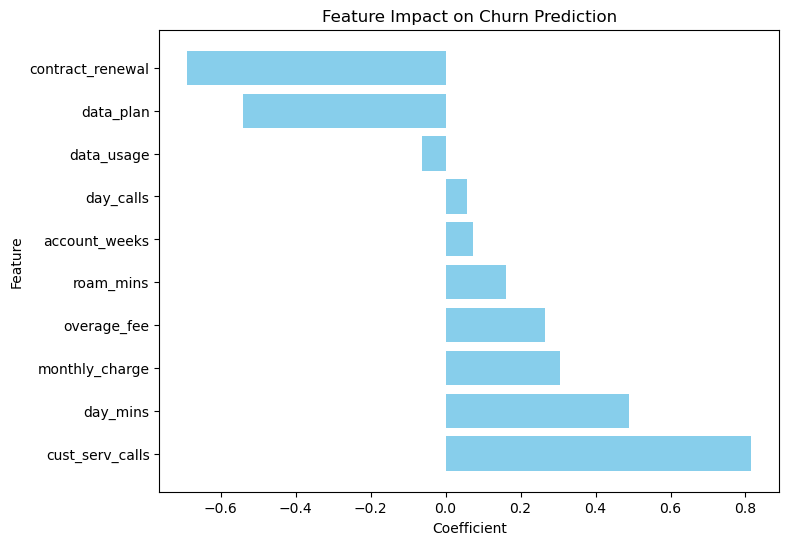

In [38]:
# Visualize Logistic Regression coefficients for each feature
x = coefficients_df["Coefficient"]
y = coefficients_df["Feature"]
plt.figure(figsize=(8, 6))
plt.barh(y,x,color = "skyblue")
plt.title("Feature Impact on Churn Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [39]:
# Create the Random Forest Model
model_rf = RandomForestClassifier(random_state = 42)

# Train the Random Forest Model
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# Predict churn classes using the model
y_rf_pred = model_rf.predict(X_test)

In [41]:
# Predict churn probabilities for the test set
y_rf_prob = model_rf.predict_proba(X_test)
y_rf_churn_prob = y_rf_prob[:,1]
y_rf_churn_prob

array([0.88, 0.04, 0.33, 0.04, 0.05, 0.01, 0.03, 0.  , 0.01, 0.09, 0.01,
       0.05, 0.03, 0.35, 0.06, 0.08, 0.03, 0.08, 0.05, 0.  , 0.  , 0.02,
       0.01, 0.33, 0.03, 0.02, 0.19, 0.86, 0.06, 0.04, 0.01, 0.01, 0.02,
       0.01, 0.04, 0.01, 0.03, 0.09, 0.01, 0.01, 0.13, 0.18, 0.  , 0.03,
       0.9 , 0.01, 0.4 , 0.05, 0.  , 0.  , 0.01, 0.54, 0.  , 0.01, 0.14,
       0.38, 0.08, 0.  , 0.  , 0.5 , 0.16, 0.27, 0.04, 0.35, 0.05, 0.75,
       0.09, 0.02, 0.05, 0.12, 0.03, 0.  , 0.83, 0.  , 0.04, 0.  , 0.43,
       0.  , 0.26, 0.04, 0.08, 0.06, 0.05, 0.89, 0.25, 0.  , 0.01, 0.01,
       0.  , 0.09, 0.04, 0.  , 0.06, 0.13, 0.03, 0.01, 0.06, 0.03, 0.05,
       0.01, 0.24, 0.55, 0.61, 0.  , 0.23, 0.16, 0.01, 0.04, 0.06, 0.13,
       0.  , 0.01, 0.01, 0.01, 0.01, 0.03, 0.  , 0.09, 0.02, 0.09, 0.01,
       0.78, 0.05, 0.  , 0.02, 0.  , 0.01, 0.  , 0.89, 0.  , 0.28, 0.04,
       0.  , 0.08, 0.04, 0.04, 0.02, 0.5 , 0.03, 0.1 , 0.01, 0.11, 0.01,
       0.01, 0.32, 0.01, 0.  , 0.07, 0.02, 0.11, 0.

In [42]:
# Calculate Accuracy Score for Random Forest Model
model_rf_accuracy = accuracy_score(y_test, y_rf_pred)
print(f"Accuracy (Random Forest) : {model_rf_accuracy * 100 :.2f} %")

Accuracy (Random Forest) : 92.50 %


In [43]:
# Calculate confusion matrix for Random Forest Model
cm_rf = confusion_matrix(y_test, y_rf_pred)
cm_rf

array([[557,  13],
       [ 37,  60]])

In [44]:
# Calculate Recall/Precision/F1/ROC-AUC Score for Random Forest Model
model_rf_recall = recall_score(y_test, y_rf_pred)
print(f"Recall Score (Random Forest) : {model_rf_recall * 100 :.2f} %")
model_rf_precision = precision_score(y_test, y_rf_pred)
print(f"Precision Score (Random Forest) : {model_rf_precision * 100 :.2f} %")
model_rf_f1 = f1_score(y_test, y_rf_pred)
print(f"F1 Score (Random Forest) : {model_rf_f1 * 100 :.2f} %")
model_rf_roc_auc = roc_auc_score(y_test, y_rf_churn_prob)
print(f"ROC-AUC Score (Random Forest) : {model_rf_roc_auc:.2f} ")

Recall Score (Random Forest) : 61.86 %
Precision Score (Random Forest) : 82.19 %
F1 Score (Random Forest) : 70.59 %
ROC-AUC Score (Random Forest) : 0.86 


In [45]:
# Get Random Forest feature importances
rf_importances = model_rf.feature_importances_
rf_importances_df = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : rf_importances
}
)
rf_importances_df.sort_values(by = "Importance", ascending = False)

,Feature,Importance
5,day_mins,0.198161
7,monthly_charge,0.173206
4,cust_serv_calls,0.144752
8,overage_fee,0.090550
9,roam_mins,0.082399
3,data_usage,0.078004
1,contract_renewal,0.070632
0,account_weeks,0.061990
6,day_calls,0.061109
2,data_plan,0.039197


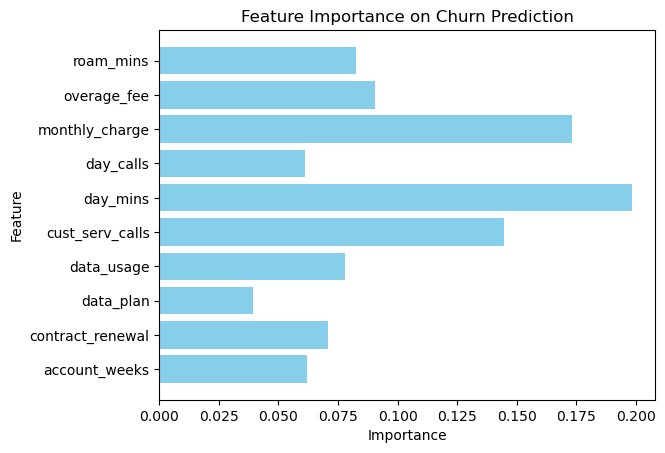

In [47]:
# Visualize Random Forest importances for each feature
x = rf_importances_df["Importance"]
y = rf_importances_df["Feature"]
plt.barh(y,x,color = "skyblue")
plt.title("Feature Importance on Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [52]:
# Compare model performance
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        model_rf_accuracy
    ],
    "Recall": [
        recall,
        recall_balanced,
        model_rf_recall
    ],
    "Precision": [
        precision,
        precision_balanced,
        model_rf_precision
    ],
    "F1": [
        f1,
        f1_balanced,
        model_rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_balanced,
        model_rf_roc_auc
    ]
})

comparison_df.round(2)

,Model,Accuracy,Recall,Precision,F1,ROC-AUC
0,Logistic Regression,0.86,0.74,0.35,0.30,0.81
1,Balanced Logistic Regression,0.76,0.74,0.35,0.47,0.81
2,Random Forest,0.93,0.62,0.82,0.71,0.86
